<a href="https://colab.research.google.com/github/heberdavi/mba-engsoft-tcc/blob/main/notebooks/03-geracao-fluxos-dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Célula 4
from graphviz import Digraph

# Estilos modernos
styles = {
    'node_base': {'shape': 'box', 'style': 'filled,rounded', 'fontname': 'Helvetica', 'fontsize': '10', 'color': '#2c3e50'},
    'edge': {'fontname': 'Helvetica', 'fontsize': '9', 'color': '#34495e'},
    'logic': {'shape': 'diamond', 'style': 'filled', 'fillcolor': '#d1d8e0', 'fontsize': '9'},
    'output': {'shape': 'cylinder', 'style': 'filled', 'fillcolor': '#e1f5fe', 'fontname': 'Helvetica-Bold', 'fontsize': '10'}
}

dot = Digraph(comment='Pipeline Proporcional Célula 4', format='png')

# --- AJUSTES DE PROPORÇÃO ---
# size="7,5": Define a largura e altura máxima em polegadas
# ratio="fill": Força o grafo a ocupar esse espaço de forma harmônica
dot.attr(rankdir='TB', size='7,5', ratio='fill', nodesep='0.5', ranksep='0.3')

# --- NÓS DO FLUXO ---
dot.node('A', 'Input: Tabela [verso]\n(SQLite)', **styles['output'])
dot.node('B', 'Tokenização e POS Tagging\n(spaCy: pt_core_news_lg)', **styles['node_base'], fillcolor='#f8f9fa')

# Decisões
dot.node('D1', 'Texto Curto?\n(< 3 carac.)', **styles['logic'])
dot.node('D2', 'Densidade Nominal?\n(PROPN > 70%)', **styles['logic'])
dot.node('D3', 'Presença de Verbo/Adj?', **styles['logic'])

# Processamento de Sucesso
dot.node('S', 'Extração do Núcleo Semântico\n(Filtro de POS Tags)', **styles['node_base'], fillcolor='#c8e6c9')

# Rótulos de Ruído
dot.node('R1', 'Label: RUIDO_CURTO', **styles['node_base'], fillcolor='#ffcdd2')
dot.node('R2', 'Label: RUIDO_NOMINAL', **styles['node_base'], fillcolor='#ffcdd2')

# Destino Único
dot.node('Z', 'Output: Tabela [verso_limpo]\n(Persistência Consolidada)', **styles['output'])

# --- CONEXÕES ---
dot.edge('A', 'B')
dot.edge('B', 'D1')

# Fluxo de Ruído 1
dot.edge('D1', 'R1', label='Sim')
dot.edge('R1', 'Z')

# Fluxo de Decisão 2
dot.edge('D1', 'D2', label='Não')
dot.edge('D2', 'D3', label='Filtro Híbrido')

# Fluxo de Ruído 2
dot.edge('D3', 'R2', label='Sim (Ruído)')
dot.edge('R2', 'Z')

# Fluxo de Sucesso
dot.edge('D3', 'S', label='Não (Válido)')
dot.edge('S', 'Z')

# Renderização
dot.render('workflow_celula_4', view=True)

'workflow_celula_4.png'

In [ ]:
# Célula 5
from graphviz import Digraph

# Estilos baseados no padrão anterior para manter a identidade visual do TCC
styles = {
    'node_base': {'shape': 'box', 'style': 'filled,rounded', 'fontname': 'Helvetica', 'fontsize': '10', 'color': '#2c3e50'},
    'model': {'shape': 'component', 'style': 'filled', 'fillcolor': '#fff3e0', 'fontname': 'Helvetica-Bold', 'fontsize': '10'},
    'logic': {'shape': 'diamond', 'style': 'filled', 'fillcolor': '#d1d8e0', 'fontsize': '9'},
    'db': {'shape': 'cylinder', 'style': 'filled', 'fillcolor': '#e1f5fe', 'fontname': 'Helvetica-Bold', 'fontsize': '10'}
}

dot = Digraph(comment='Pipeline Célula 5', format='png')

# Ajustes de Proporção (Retângulo Harmônico)
dot.attr(rankdir='TB', size='8,6', ratio='fill', nodesep='0.4', ranksep='0.4')

# --- NÓS DO FLUXO ---

# Entrada
dot.node('A', 'Input: Texto Limpo\n(Tabela verso_limpo)', **styles['db'])

# Modelo de IA
dot.node('B', 'BERTopic + BERTimbau\n(Zero-Shot Learning)', **styles['model'])
dot.node('C', 'Descrições de Eixos\n(Âncoras Semânticas)', **styles['node_base'], fillcolor='#f8f9fa')

# Processamento de Similaridade
dot.node('D', 'Matriz de Probabilidades\n(Esgotamento, Transitoriedade, Insignificância, Narrativo)', **styles['node_base'], fillcolor='#ffffff')

# Lógica de Veto Metodológico
dot.node('E', 'O Gênero é Subjetivo?\n(Poético, Profético, etc.)', **styles['logic'])

# Ramificações de Veto
dot.node('F1', 'Rigor Máximo:\nVeto se Narrativo > 30%', **styles['node_base'], fillcolor='#ffebee')
dot.node('F2', 'Flexibilidade:\nVeto se Narrativo > 55%', **styles['node_base'], fillcolor='#e8f5e9')

# Resultado Final
dot.node('G', 'Classificação Final:\nEixos Existenciais ou "Outros"', **styles['node_base'], fillcolor='#c8e6c9')
dot.node('Z', 'Output: Tabelas [topico] e [verso_topico]\n(Persistência SQLite)', **styles['db'])

# --- CONEXÕES ---
dot.edge('A', 'B')
dot.edge('C', 'B')
dot.edge('B', 'D')
dot.edge('D', 'E')

# Bifurcação da Lógica de Veto
dot.edge('E', 'F1', label='Não (Histórico/Pentateuco)')
dot.edge('E', 'F2', label='Sim (Existencial)')

# Convergência para persistência
dot.edge('F1', 'G')
dot.edge('F2', 'G')
dot.edge('G', 'Z')

# Renderização
dot.render('workflow_celula_5', view=True)

'workflow_celula_5.png'

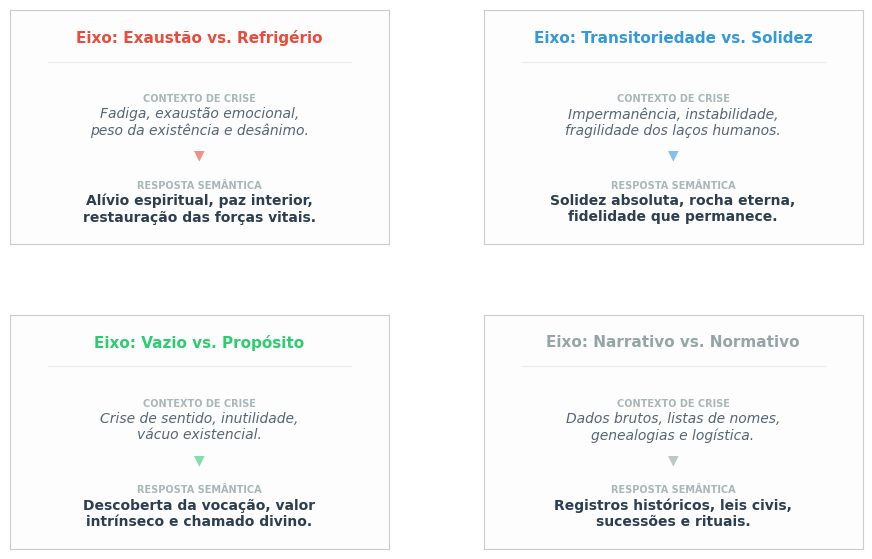

In [ ]:
# Célula 5 - Âncoras semânticas
import matplotlib.pyplot as plt

# Dados estruturados com foco nos conceitos (sem menção aos autores)
eixos = [
    {"titulo": "Eixo: Exaustão vs. Refrigério",
     "crise": "Fadiga, exaustão emocional,\npeso da existência e desânimo.",
     "antidoto": "Alívio espiritual, paz interior,\nrestauração das forças vitais.",
     "cor": "#e74c3c"},

    {"titulo": "Eixo: Transitoriedade vs. Solidez",
     "crise": "Impermanência, instabilidade,\nfragilidade dos laços humanos.",
     "antidoto": "Solidez absoluta, rocha eterna,\nfidelidade que permanece.",
     "cor": "#3498db"},

    {"titulo": "Eixo: Vazio vs. Propósito",
     "crise": "Crise de sentido, inutilidade,\nvácuo existencial.",
     "antidoto": "Descoberta da vocação, valor\nintrínseco e chamado divino.",
     "cor": "#2ecc71"},

    {"titulo": "Eixo: Narrativo vs. Normativo",
     "crise": "Dados brutos, listas de nomes,\ngenealogias e logística.",
     "antidoto": "Registros históricos, leis civis,\nsucessões e rituais.",
     "cor": "#95a5a6"}
]

# Configuração da figura (ajustada para proporção retangular harmônica)
fig, axs = plt.subplots(2, 2, figsize=(11, 7))
plt.subplots_adjust(hspace=0.3, wspace=0.25)
fig.patch.set_facecolor('#ffffff')

for i, ax in enumerate(axs.flat):
    eixo = eixos[i]

    # Estética do card
    ax.set_facecolor('#fdfdfd')
    for spine in ax.spines.values():
        spine.set_color('#cccccc')
        spine.set_linewidth(0.8)

    # Título do Eixo (Conceitual)
    ax.text(0.5, 0.88, eixo["titulo"], ha='center', va='center',
            fontsize=11, fontweight='bold', color=eixo["cor"])

    # Linha divisória sutil
    ax.axhline(0.78, color='#eeeeee', linewidth=1, xmin=0.1, xmax=0.9)

    # Camada da Crise
    ax.text(0.5, 0.62, "CONTEXTO DE CRISE", ha='center', va='center',
            fontsize=7, fontweight='bold', color='#95a5a6', alpha=0.8)
    ax.text(0.5, 0.52, eixo["crise"], ha='center', va='center',
            fontsize=10, fontstyle='italic', color='#576574')

    # Indicador de Transição
    ax.text(0.5, 0.38, "▼", ha='center', va='center', fontsize=10, color=eixo["cor"], alpha=0.6)

    # Camada do Antídoto
    ax.text(0.5, 0.25, "RESPOSTA SEMÂNTICA", ha='center', va='center',
            fontsize=7, fontweight='bold', color='#95a5a6', alpha=0.8)
    ax.text(0.5, 0.15, eixo["antidoto"], ha='center', va='center',
            fontsize=10, fontweight='bold', color='#2c3e50')

    # Limpeza de eixos
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Salvamento em alta resolução
plt.savefig('ancoras_semanticas.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Célula 6
from graphviz import Digraph

# Estilos consolidados para identidade visual única
styles = {
    'node_base': {'shape': 'box', 'style': 'filled,rounded', 'fontname': 'Helvetica', 'fontsize': '10', 'color': '#2c3e50'},
    'model': {'shape': 'component', 'style': 'filled', 'fillcolor': '#fff3e0', 'fontname': 'Helvetica-Bold', 'fontsize': '10'},
    'db': {'shape': 'cylinder', 'style': 'filled', 'fillcolor': '#e1f5fe', 'fontname': 'Helvetica-Bold', 'fontsize': '10'},
    'batch': {'shape': 'stack', 'style': 'filled', 'fillcolor': '#f8f9fa', 'fontname': 'Helvetica', 'fontsize': '9'}
}

dot = Digraph(comment='Pipeline Célula 6', format='png')

# Ajustes de Proporção Retangular (7,5 x 5,5)
dot.attr(rankdir='TB', size='7.5,5.5', ratio='fill', nodesep='0.5', ranksep='0.4')

# --- NÓS DO FLUXO ---

# Entrada de Dados Cruzados
dot.node('A', 'Input: Texto + Tópicos\n(JOIN: verso & verso_topico)', **styles['db'])

# Motor de Inferência
dot.node('B', 'Transformer: BERTimbau\n(pysentimiento: Sentiment Task)', **styles['model'])

# Processamento Otimizado
dot.node('C', 'Batch Processing\n(Size = 64 | GPU Accel)', **styles['batch'])

# Classificação e Mapeamento
dot.node('D', 'Categorização de Polaridade\n[Positiva (1) | Neutra (0) | Negativa (-1)]', **styles['node_base'], fillcolor='#ffffff')

# Persistência
dot.node('E', 'Persistência: Tabela [verso_sentimento]\n(Valência e Scores)', **styles['db'])

# Camada de Análise Final (Resumo Executivo)
dot.node('F', 'Cruzamento Estatístico:\nDiagnóstico vs. Antídoto', **styles['node_base'], fillcolor='#c8e6c9')

# Saída Final
dot.node('Z', 'Output: Resumo Executivo\n(Insights Existenciais)', shape='doubleoctagon', style='filled', fillcolor='#2c3e50', fontcolor='white', fontsize='10')

# --- CONEXÕES ---
dot.edge('A', 'C')
dot.edge('C', 'B')
dot.edge('B', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'Z')

# Renderização
dot.render('workflow_celula_6', view=True)

'workflow_celula_6.png'

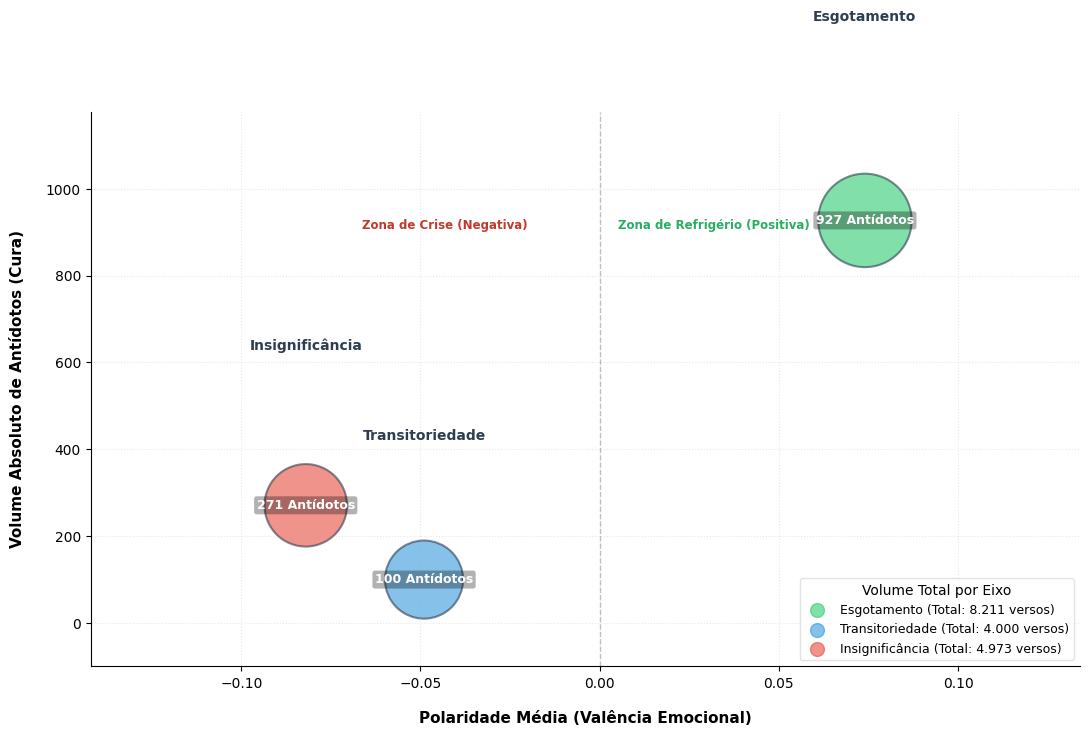

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dados extraídos da sua consulta SQL
data = {
    'Eixo': ['Esgotamento', 'Transitoriedade', 'Insignificância'],
    'Total_Versos': [8211, 4000, 4973],
    'Antidotos_Cura': [927, 100, 271],
    'Polaridade_Media': [0.074, -0.049, -0.082]
}

df = pd.DataFrame(data)

# Cores consistentes
cores = ['#2ecc71', '#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(11, 7.5))
fig.patch.set_facecolor('#ffffff')

# Escalonamento das bolhas (ajustado para o volume total de versos)
# Usamos sqrt para que a *área* seja proporcional ao volume
sizes = np.sqrt(df['Total_Versos']) * 50

# Geração do Bubble Chart
scatter = ax.scatter(
    df['Polaridade_Media'],
    df['Antidotos_Cura'],
    s=sizes,
    c=cores,
    alpha=0.6,
    edgecolors="#2c3e50",
    linewidth=1.5
)

# --- NOVA LÓGICA DE LEGENDA EXTERNA ---
# Criamos "proxies" (elementos invisíveis) para gerar a legenda com os totais
for i, eixo in enumerate(df['Eixo']):
    ax.scatter([], [], c=cores[i], alpha=0.6, s=100,
               label=f"{eixo} (Total: {df['Total_Versos'][i]:,} versos)".replace(',', '.'))

# Posicionamento da legenda
ax.legend(title="Volume Total por Eixo", loc='lower right', frameon=True,
          facecolor='white', edgecolor='#dddddd', fontsize=9, title_fontsize=10)


# --- NOVA LÓGICA DE ROTULAGEM INTERNA ---
# Colocamos o total de ANTÍDOTOS dentro ou muito próximo da bolha
for i, txt in enumerate(df['Eixo']):
    # Nome do Eixo acima da bolha
    ax.text(
        df['Polaridade_Media'][i],
        df['Antidotos_Cura'][i] + (sizes[i] * 0.1), # Offset baseado no tamanho da bolha
        txt,
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#2c3e50'
    )
    # Número de ANTÍDOTOS dentro da bolha (em branco para contraste)
    ax.text(
        df['Polaridade_Media'][i],
        df['Antidotos_Cura'][i],
        f"{df['Antidotos_Cura'][i]} Antídotos",
        ha='center', va='center',
        fontsize=9, fontweight='bold', color='white',
        bbox=dict(facecolor='black', alpha=0.3, edgecolor='none', boxstyle='round,pad=0.2')
    )


# Linhas de referência (Eixo Zero de Polaridade)
ax.axvline(0, color='#7f8c8d', linestyle='--', linewidth=1, alpha=0.5)
ax.text(0.005, df['Antidotos_Cura'].max() * 0.98, 'Zona de Refrigério (Positiva)',
        fontsize=8.5, color='#27ae60', fontweight='bold')
ax.text(-0.02, df['Antidotos_Cura'].max() * 0.98, 'Zona de Crise (Negativa)',
        fontsize=8.5, color='#c0392b', fontweight='bold', ha='right')

# Estilização dos eixos
ax.set_xlabel('Polaridade Média (Valência Emocional)', fontsize=11, fontweight='bold', labelpad=15)
ax.set_ylabel('Volume Absoluto de Antídotos (Cura)', fontsize=11, fontweight='bold', labelpad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.3)

# Ajuste de margens para as bolhas não cortarem
ax.set_xlim(df['Polaridade_Media'].min() - 0.06, df['Polaridade_Media'].max() + 0.06)
ax.set_ylim(-100, df['Antidotos_Cura'].max() + 250)

plt.tight_layout()
plt.savefig('bubble_chart_executivo.png', dpi=300, bbox_inches='tight')
plt.show()

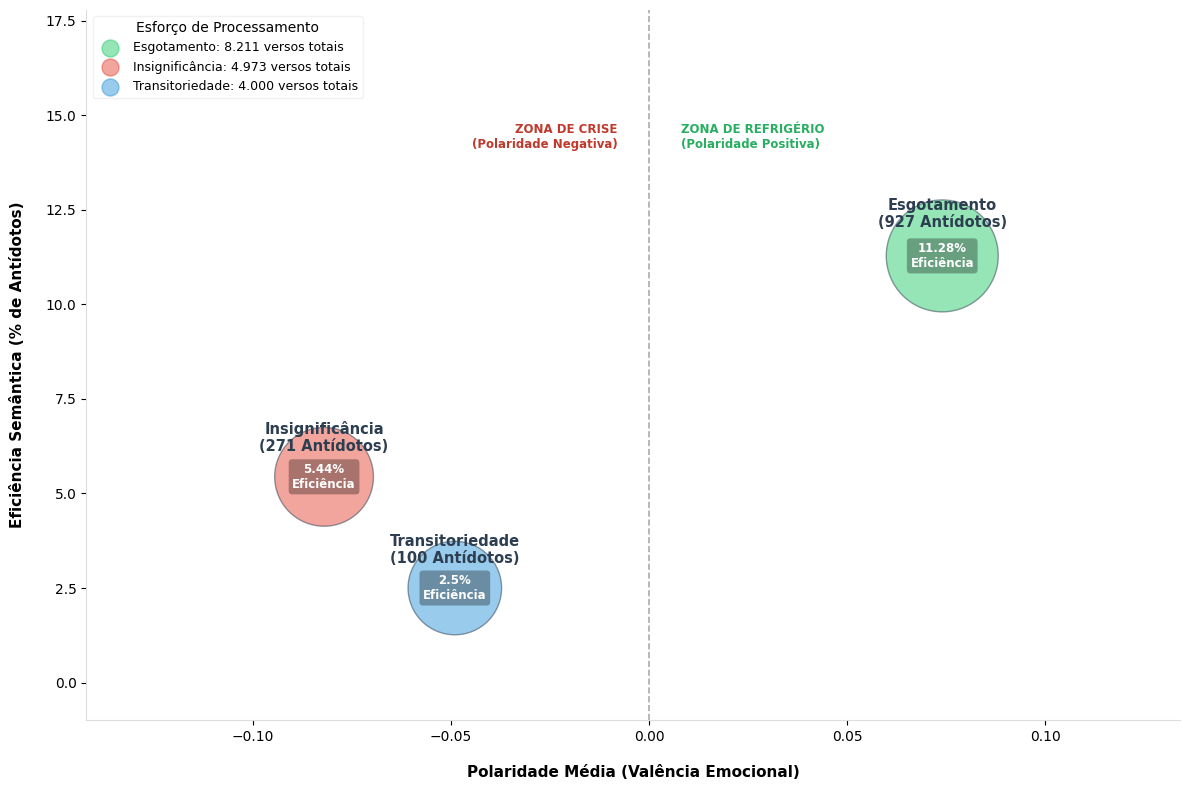

In [ ]:
# Matriz de eficiência existencial
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Dados Consolidados (Pré-processamento da Célula 5 e 6)
data = {
    'Eixo': ['Esgotamento', 'Insignificância', 'Transitoriedade'],
    'Total_Eixo': [8211, 4973, 4000],      # Total de versos processados
    'Total_Antidotos': [927, 271, 100],   # Total de versos positivos (Cura)
    'Polaridade': [0.074, -0.082, -0.049],
    'Eficiencia': [11.28, 5.44, 2.50]
}

df = pd.DataFrame(data)

# Cores suaves e consistentes (Verde, Vermelho, Azul)
cores = ['#2ecc71', '#e74c3c', '#3498db']

# 2. Configuração do Gráfico (Minimalista Clean)
fig, ax = plt.subplots(figsize=(12, 8)) # Aumentado para acomodar os textos superiores
fig.patch.set_facecolor('#ffffff') # Fundo branco puro
ax.set_facecolor('#ffffff') # Fundo do gráfico branco

# 3. Definição do Tamanho das Bolhas
# Usamos sqrt para que a ÁREA seja proporcional ao volume processado
tamanho_base = 6500
sizes = np.sqrt(df['Total_Eixo']) * tamanho_base / np.sqrt(df['Total_Eixo'].max())

# 4. Geração do Bubble Chart (Plotagem Principal)
scatter = ax.scatter(
    df['Polaridade'],
    df['Eficiencia'],
    s=sizes,
    c=cores,
    alpha=0.5, # Transparência para sobreposições sutis
    edgecolors="#2c3e50", # Borda escura para definição
    linewidth=1.0,
    zorder=3 # Garante que as bolhas fiquem sobre a linha tracejada
)

# 5. Rótulos Dinâmicos Integrados (Lógica de Engenharia Visual)
# Calculamos um offset dinâmico baseado no raio da bolha para evitar sobreposição
offsets_texto = np.sqrt(sizes) * 0.0085

for i, row in df.iterrows():
    # A) NOME DO EIXO + TOTAL DE ANTÍDOTOS (Acima da bolha)
    # Formatação com separador de milhar brasileiro
    ax.text(
        row['Polaridade'],
        row['Eficiencia'] + offsets_texto[i],
        f"{row['Eixo']}\n({int(row['Total_Antidotos'])} Antídotos)",
        ha='center', va='bottom',
        fontsize=10.5, fontweight='bold', color='#2c3e50',
        linespacing=1.2
    )

    # B) EFICIÊNCIA % (Centro da bolha, com caixa de contraste)
    ax.text(
        row['Polaridade'],
        row['Eficiencia'],
        f"{row['Eficiencia']}%\nEficiência",
        ha='center', va='center',
        fontsize=8.5, fontweight='bold', color='white',
        bbox=dict(facecolor='black', alpha=0.3, edgecolor='none', boxstyle='round,pad=0.3')
    )

# 6. Linha Única de Separação e Textos Interpretativos (As Zonas)
# Eixo Zero de Polaridade (Tracejado sutil)
ax.axvline(0, color='#7f8c8d', linestyle='--', linewidth=1.2, alpha=0.7, zorder=1)

# Textos das Zonas de Interpretação Sociológica (com margem superior)
ax.text(0.008, df['Eficiencia'].max() + 3.5, 'ZONA DE REFRIGÉRIO\n(Polaridade Positiva)',
        fontsize=8.5, color='#27ae60', fontweight='bold', ha='left', va='top')
ax.text(-0.008, df['Eficiencia'].max() + 3.5, 'ZONA DE CRISE\n(Polaridade Negativa)',
        fontsize=8.5, color='#c0392b', fontweight='bold', ha='right', va='top')

# 7. Legenda Externa (Total de Versos Processados)
for i, eixo in enumerate(df['Eixo']):
    ax.scatter([], [], c=cores[i], alpha=0.5, s=150,
               label=f"{eixo}: {df['Total_Eixo'][i]:,} versos totais".replace(',', '.'))

ax.legend(title="Esforço de Processamento", loc='upper left',
          frameon=True, facecolor='white', edgecolor='#eeeeee',
          fontsize=9, title_fontsize=10)

# 8. Estilização Final dos Eixos (Sem Grid)
ax.set_xlabel('Polaridade Média (Valência Emocional)', fontsize=11, fontweight='bold', labelpad=15)
ax.set_ylabel('Eficiência Semântica (% de Antídotos)', fontsize=11, fontweight='bold', labelpad=15)

# Remove bordas superiores e direitas para minimalismo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

# 9. Ajuste de Limites (Essencial para limpeza)
# Aumentamos o limite superior de Y (+6.5) para acomodar os textos das zonas
ax.set_xlim(df['Polaridade'].min() - 0.06, df['Polaridade'].max() + 0.06)
ax.set_ylim(-1, df['Eficiencia'].max() + 6.5)

plt.tight_layout()
plt.savefig('matriz_eficiencia_existencial.png', dpi=300, bbox_inches='tight')
plt.show()